In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load the CSV files
gist_csv = '/mnthdd/cpanourg/2-hdvc/results/relerr/gist_PQ_adc_vs_exact_eval.csv'
deep_csv = '/mnthdd/cpanourg/2-hdvc/results/relerr/deep_PQ_adc_vs_exact_eval.csv'
glove_csv = '/mnthdd/cpanourg/2-hdvc/results/relerr/glove_200d_PQ_adc_vs_exact_eval.csv'

# Load data
df_gist = pd.read_csv(gist_csv)
df_deep = pd.read_csv(deep_csv)
df_glove = pd.read_csv(glove_csv)

# Add dataset column if not present
df_gist['dataset'] = 'gist'
df_deep['dataset'] = 'deep'
df_glove['dataset'] = 'glove'

# Combine datasets
df_all = pd.concat([df_gist, df_deep, df_glove], ignore_index=True)

print(f"Gist dataset shape: {df_gist.shape}")
print(f"Deep dataset shape: {df_deep.shape}")
print(f"Glove dataset shape: {df_glove.shape}")

print(f"\nGist - nbits values: {sorted(df_gist['nbits'].unique())}")
print(f"Deep - nbits values: {sorted(df_deep['nbits'].unique())}")
print(f"Glove - nbits values: {sorted(df_glove['nbits'].unique())}")

train_sizes = [500000, 100000000, 1000000]
divisor = [1000, 1000000, 1000000]
letters = ['K', 'M', 'M']
nbits_values = [8, 10]

# Filter for nbits == 8 and nbits == 10
df_gist_filtered_8 = df_gist[(df_gist['nbits'] == 8) & (df_gist['train_size'] == train_sizes[0])].copy()
df_deep_filtered_8 = df_deep[(df_deep['nbits'] == 8) & (df_deep['train_size'] == train_sizes[1])].copy()
df_glove_filtered_8 = df_glove[(df_glove['nbits'] == 8) & (df_glove['train_size'] == train_sizes[2])].copy()

df_gist_filtered_10 = df_gist[(df_gist['nbits'] == 10) & (df_gist['train_size'] == train_sizes[0])].copy()
df_deep_filtered_10 = df_deep[(df_deep['nbits'] == 10) & (df_deep['train_size'] == train_sizes[1])].copy()
df_glove_filtered_10 = df_glove[(df_glove['nbits'] == 10) & (df_glove['train_size'] == train_sizes[2])].copy()

print(f"\nGist filtered (nbits=8, train_size={train_sizes[0]//divisor[0]}{letters[0]}): {len(df_gist_filtered_8)} rows")
print(f"Deep filtered (nbits=8, train_size={train_sizes[1]//divisor[1]}{letters[1]}): {len(df_deep_filtered_8)} rows")
print(f"Glove filtered (nbits=8, train_size={train_sizes[2]//divisor[2]}{letters[2]}): {len(df_glove_filtered_8)} rows")

print(f"\nGist filtered (nbits=10, train_size={train_sizes[0]//divisor[0]}{letters[0]}): {len(df_gist_filtered_10)} rows")
print(f"Deep filtered (nbits=10, train_size={train_sizes[1]//divisor[1]}{letters[1]}): {len(df_deep_filtered_10)} rows")
print(f"Glove filtered (nbits=10, train_size={train_sizes[2]//divisor[2]}{letters[2]}): {len(df_glove_filtered_10)} rows")

print(f"\nGist (nbits=8) - n_subquantizers values available: {sorted(df_gist_filtered_8['n_subquantizers'].unique())}")
print(f"Deep (nbits=8) - n_subquantizers values available: {sorted(df_deep_filtered_8['n_subquantizers'].unique())}")
print(f"Glove (nbits=8) - n_subquantizers values available: {sorted(df_glove_filtered_8['n_subquantizers'].unique())}")

print(f"\nGist (nbits=10) - n_subquantizers values available: {sorted(df_gist_filtered_10['n_subquantizers'].unique())}")
print(f"Deep (nbits=10) - n_subquantizers values available: {sorted(df_deep_filtered_10['n_subquantizers'].unique())}")
print(f"Glove (nbits=10) - n_subquantizers values available: {sorted(df_glove_filtered_10['n_subquantizers'].unique())}")


Gist dataset shape: (96, 23)
Deep dataset shape: (79, 23)
Glove dataset shape: (36, 18)

Gist - nbits values: [4, 5, 6, 8, 10, 12, 14, 16]
Deep - nbits values: [4, 6, 8, 10, 12, 14, 16]
Glove - nbits values: [4, 5, 6, 7, 8, 9, 10]

Gist filtered (nbits=8, train_size=500K): 17 rows
Deep filtered (nbits=8, train_size=100M): 16 rows
Glove filtered (nbits=8, train_size=1M): 12 rows

Gist filtered (nbits=10, train_size=500K): 33 rows
Deep filtered (nbits=10, train_size=100M): 15 rows
Glove filtered (nbits=10, train_size=1M): 14 rows

Gist (nbits=8) - n_subquantizers values available: [1, 4, 8, 16, 32, 64, 80, 96, 120, 160, 192, 240, 320, 480, 960]
Deep (nbits=8) - n_subquantizers values available: [1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 96]
Glove (nbits=8) - n_subquantizers values available: [1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 200]

Gist (nbits=10) - n_subquantizers values available: [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 16, 20, 24, 30, 32, 40, 48, 60, 64, 80, 96, 120, 160, 192, 240, 320, 4

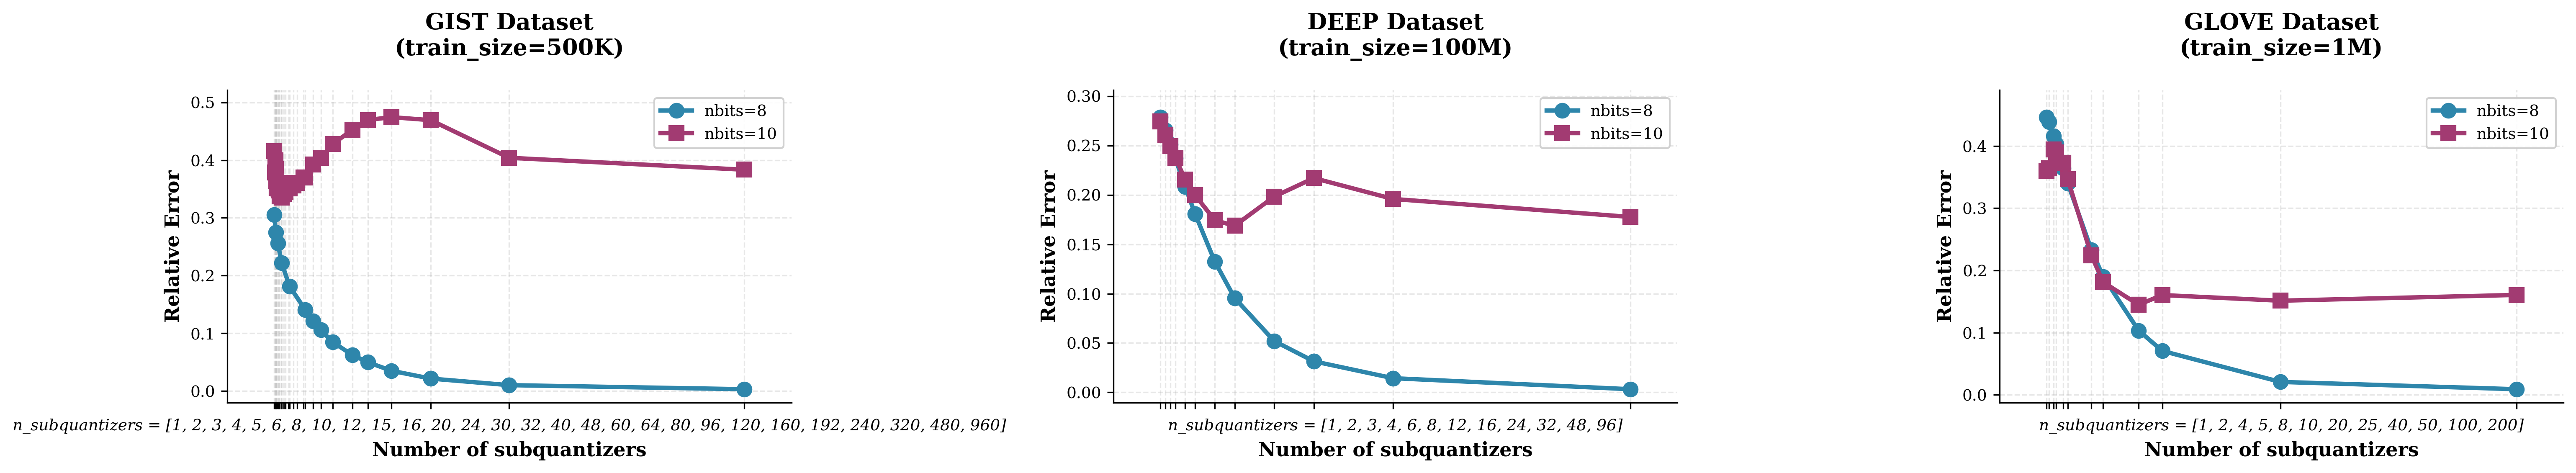


Summary: Impact of n_subquantizers on relative error (nbits=8 and nbits=10)

GIST Dataset (nbits=8):
  n_subquantizers=  1: rel_error_mean=0.3054
  n_subquantizers=  4: rel_error_mean=0.2751
  n_subquantizers=  8: rel_error_mean=0.2561
  n_subquantizers= 16: rel_error_mean=0.2218
  n_subquantizers= 32: rel_error_mean=0.1814
  n_subquantizers= 64: rel_error_mean=0.1407
  n_subquantizers= 80: rel_error_mean=0.1214
  n_subquantizers= 96: rel_error_mean=0.1056
  n_subquantizers=120: rel_error_mean=0.0848
  n_subquantizers=160: rel_error_mean=0.0625
  n_subquantizers=192: rel_error_mean=0.0498
  n_subquantizers=240: rel_error_mean=0.0350
  n_subquantizers=320: rel_error_mean=0.0215
  n_subquantizers=320: rel_error_mean=0.0215
  n_subquantizers=480: rel_error_mean=0.0101
  n_subquantizers=480: rel_error_mean=0.0101
  n_subquantizers=960: rel_error_mean=0.0031

GIST Dataset (nbits=10):
  n_subquantizers=  1: rel_error_mean=0.4155
  n_subquantizers=  1: rel_error_mean=0.4155
  n_subquantizers

In [2]:
# Set style (paper-quality minimalist)
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "serif",
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Create plots for each dataset
datasets = [
    ('gist', df_gist_filtered_8, df_gist_filtered_10),
    ('deep', df_deep_filtered_8, df_deep_filtered_10),
    ('glove', df_glove_filtered_8, df_glove_filtered_10)
]

# Colors for nbits=8 and nbits=10
colors = {'8': '#2E86AB', '10': '#A23B72'}  # Blue for nbits=8, Purple/Pink for nbits=10

# Increase figure size for better visibility
fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5))

# If only one dataset, axes might be a single object
if len(datasets) == 1:
    axes = [axes]

for idx, (dataset_name, df_filtered_8, df_filtered_10) in enumerate(datasets):
    ax = axes[idx]
    
    # Check if we have data for either nbits value
    has_data_8 = len(df_filtered_8) > 0
    has_data_10 = len(df_filtered_10) > 0
    
    if not has_data_8 and not has_data_10:
        ax.text(0.5, 0.5, f'No data for {dataset_name}\n(train_size={train_sizes[idx]//divisor[idx]}{letters[idx]})', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{dataset_name.upper()} Dataset\n(train_size={train_sizes[idx]//divisor[idx]}{letters[idx]})', fontweight='bold')
        continue
    
    # Plot nbits=8
    if has_data_8:
        df_sorted_8 = df_filtered_8.sort_values('n_subquantizers')
        ax.plot(
            df_sorted_8['n_subquantizers'], 
            df_sorted_8['rel_error_mean'],
            marker='o',
            markersize=8,
            linewidth=2.5,
            color=colors['8'],
            label='nbits=8',
            zorder=3
        )
    
    # Plot nbits=10
    if has_data_10:
        df_sorted_10 = df_filtered_10.sort_values('n_subquantizers')
        ax.plot(
            df_sorted_10['n_subquantizers'], 
            df_sorted_10['rel_error_mean'],
            marker='s',
            markersize=8,
            linewidth=2.5,
            color=colors['10'],
            label='nbits=10',
            zorder=3
        )
    
    # Styling
    ax.set_xlabel('Number of subquantizers', fontsize=11, fontweight='bold', labelpad=15)
    ax.set_ylabel('Relative Error', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name.upper()} Dataset\n(train_size={train_sizes[idx]//divisor[idx]}{letters[idx]})', 
                 fontsize=13, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, which='both')
    ax.legend(fontsize=9, loc='best', framealpha=0.9)
    
    # Get all unique n_subquantizers values from both datasets
    all_nsub = set()
    if has_data_8:
        all_nsub.update(df_filtered_8['n_subquantizers'].unique())
    if has_data_10:
        all_nsub.update(df_filtered_10['n_subquantizers'].unique())
    unique_nsub = sorted(all_nsub)
    
    # Set x-axis ticks but remove labels - show values as list instead
    ax.set_xticks(unique_nsub)
    ax.set_xticklabels([])  # Remove all tick labels
    
    # Add text box below showing all x-axis values as a list (above the xlabel)
    nsub_list_str = ', '.join([str(int(x)) for x in unique_nsub])
    ax.text(0.5, -0.05, f'n_subquantizers = [{nsub_list_str}]', 
            transform=ax.transAxes, ha='center', va='top', 
            fontsize=9, style='italic')
    
    # Set reasonable y-axis limits with some padding (considering both datasets)
    y_min = float('inf')
    y_max = float('-inf')
    if has_data_8:
        y_min = min(y_min, df_filtered_8['rel_error_mean'].min())
        y_max = max(y_max, df_filtered_8['rel_error_mean'].max())
    if has_data_10:
        y_min = min(y_min, df_filtered_10['rel_error_mean'].min())
        y_max = max(y_max, df_filtered_10['rel_error_mean'].max())
    
    y_range = y_max - y_min
    ax.set_ylim(max(-0.5, y_min - y_range * 0.05), y_max + y_range * 0.1)
    # Better margins (extra bottom margin for the text)
    ax.margins(x=0.1, y=0.05)

plt.tight_layout(pad=3.0, rect=[0, 0.10, 1, 0.98])
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("Summary: Impact of n_subquantizers on relative error (nbits=8 and nbits=10)")
print("="*70)
for dataset_name, df_filtered_8, df_filtered_10 in datasets:
    if len(df_filtered_8) == 0 and len(df_filtered_10) == 0:
        continue
    
    if len(df_filtered_8) > 0:
        df_sorted_8 = df_filtered_8.sort_values('n_subquantizers')
        print(f"\n{dataset_name.upper()} Dataset (nbits=8):")
        for _, row in df_sorted_8.iterrows():
            print(f"  n_subquantizers={row['n_subquantizers']:3d}: rel_error_mean={row['rel_error_mean']:.4f}")
    
    if len(df_filtered_10) > 0:
        df_sorted_10 = df_filtered_10.sort_values('n_subquantizers')
        print(f"\n{dataset_name.upper()} Dataset (nbits=10):")
        for _, row in df_sorted_10.iterrows():
            print(f"  n_subquantizers={row['n_subquantizers']:3d}: rel_error_mean={row['rel_error_mean']:.4f}")


In [3]:
0.003/0.01

0.3